# Actividad Guiada 3 (AG3): Metaheurísticas para el TSP (swiss42.tsp)
**Alumno:** Iván Alcamán Painén  
**Asignatura:** Algoritmos de Optimización / Inteligencia Artificial (MIAR)  
**URL Repositorio GitHub:** [https://github.com/IAPGMAIL/AG3---Actividad-Guiada-3](https://github.com/IAPGMAIL/AG3---Actividad-Guiada-3)  
**URL Google Colab:** [https://colab.research.google.com/github/IAPGMAIL/AG3---Actividad-Guiada-3/blob/main/AG3_Ivan_Alcaman_Painen.ipynb](https://colab.research.google.com/github/IAPGMAIL/AG3---Actividad-Guiada-3/blob/main/AG3_Ivan_Alcaman_Painen.ipynb)  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IAPGMAIL/AG3---Actividad-Guiada-3/blob/main/AG3_Ivan_Alcaman_Painen.ipynb)

---


## 1. Carga de Librerías y Configuración del Entorno

In [26]:
import warnings
warnings.filterwarnings('ignore')

# Instalar tsplib95 si no estuviera disponible
!pip install tsplib95 -q

import tsplib95
import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import MDS

## 2. Carga del Fichero `swiss42.tsp` y Matriz Precomputada
Cargamos los datos del problema y precomputamos la matriz de distancias para optimizar los tiempos de cálculo de los algoritmos.

In [27]:
# Cargar la instancia del problema swiss42.tsp
import os
import urllib.request

file = 'swiss42.tsp'

# Si el archivo no existe localmente (ej. en Google Colab), se descarga automáticamente desde GitHub
if not os.path.exists(file):
    print('Descargando swiss42.tsp desde GitHub para Google Colab...')
    url = 'https://raw.githubusercontent.com/IAPGMAIL/AG3---Actividad-Guiada-3/main/swiss42.tsp'
    urllib.request.urlretrieve(url, file)

problem = tsplib95.load(file)

Nodos = list(problem.get_nodes())
num_nodos = len(Nodos)

print(f"Nombre del problema: {problem.name}")
print(f"Número de ciudades (nodos): {num_nodos}")

# Matriz de distancias precomputada (optimización de velocidad)
dist_matrix = [[problem.get_weight(Nodos[i], Nodos[j]) for j in range(num_nodos)] for i in range(num_nodos)]

def crear_solucion():
    """Genera una solución aleatoria que comienza en la ciudad 0 y visita las 41 restantes."""
    sol = list(range(num_nodos))
    resto = sol[1:]
    random.shuffle(resto)
    return [0] + resto

def distancia_total(solucion):
    """Calcula la distancia total del circuito cerrado para una solución dada."""
    dist = 0
    for i in range(num_nodos - 1):
        dist += dist_matrix[solucion[i]][solucion[i+1]]
    dist += dist_matrix[solucion[-1]][solucion[0]]
    return dist

# Ejemplo de evaluación
sol_ejemplo = crear_solucion()
print("Solución inicial aleatoria (índices):", sol_ejemplo[:10], "...")
print("Distancia total inicial:", distancia_total(sol_ejemplo))


Nombre del problema: swiss42
Número de ciudades (nodos): 42
Solución inicial aleatoria (índices): [0, 20, 15, 25, 22, 17, 16, 19, 24, 27] ...
Distancia total inicial: 4788


## 3. Función de Visualización del Grafo (MDS)
Proyecta las ciudades en 2D mediante Multidimensional Scaling (MDS) a partir de la matriz de distancias y dibuja el recorrido.

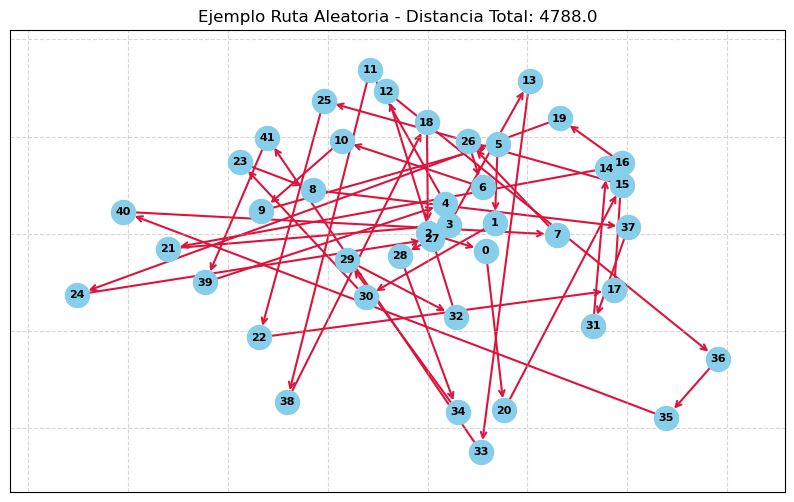

In [28]:
def plot_tsp_solution(distance_matrix, tsp_solution, titulo="Solución TSP"):
    """Dibuja el grafo del TSP proyectado con MDS."""
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4)
    pos = mds.fit_transform(np.array(distance_matrix))
    
    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()
    for i in range(len(tsp_solution)):
        G.add_node(tsp_solution[i])
        u = tsp_solution[i]
        v = tsp_solution[(i + 1) % len(tsp_solution)]
        G.add_edge(u, v)
        
    pos_dict = {i: pos[i] for i in range(len(pos))}
    
    nx.draw_networkx_nodes(G, pos_dict, node_color='skyblue', node_size=300)
    nx.draw_networkx_labels(G, pos_dict, font_size=8, font_weight='bold')
    nx.draw_networkx_edges(G, pos_dict, edge_color='crimson', width=1.5, arrowstyle='->', arrowsize=10)
    
    plt.title(f"{titulo} - Distancia Total: {distancia_total(tsp_solution):.1f}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Probar visualización con la solución aleatoria
plot_tsp_solution(dist_matrix, sol_ejemplo, "Ejemplo Ruta Aleatoria")

## 4. Metaheurísticas Base

### 4.1 Búsqueda Aleatoria (Random Search)
Exploración por muestreo uniforme independiente en el espacio de soluciones.

In [29]:
def busqueda_aleatoria(iteraciones=10000):
    """Genera 'iteraciones' soluciones al azar y conserva la mejor."""
    mejor_sol = crear_solucion()
    mejor_dist = distancia_total(mejor_sol)
    
    for _ in range(iteraciones):
        sol = crear_solucion()
        d = distancia_total(sol)
        if d < mejor_dist:
            mejor_dist = d
            mejor_sol = sol
            
    return mejor_sol, mejor_dist

t0 = time.time()
sol_ra, dist_ra = busqueda_aleatoria(10000)
t_ra = time.time() - t0
print(f"Búsqueda Aleatoria (10,000 iter): Mejor Distancia = {dist_ra:.1f} | Tiempo: {t_ra:.3f} s")

Búsqueda Aleatoria (10,000 iter): Mejor Distancia = 3707.0 | Tiempo: 0.196 s


### 4.2 Búsqueda Local (Local Search con 2-opt)
Exploración de la vecindad 2-opt (invirtiendo el subcamino entre dos ciudades $i$ y $j$) descendiendo iterativamente hasta alcanzar un óptimo local.

In [30]:
def busqueda_local_2opt(solucion_inicial=None):
    """Búsqueda local con el operador 2-opt (Primer Mejor Vecino)."""
    if solucion_inicial is None:
        sol_actual = crear_solucion()
    else:
        sol_actual = list(solucion_inicial)
    
    dist_actual = distancia_total(sol_actual)
    
    mejora = True
    while mejora:
        mejora = False
        for i in range(1, num_nodos - 1):
            for j in range(i + 1, num_nodos):
                vecina = sol_actual[:i] + sol_actual[i:j+1][::-1] + sol_actual[j+1:]
                d_v = distancia_total(vecina)
                if d_v < dist_actual:
                    sol_actual = vecina
                    dist_actual = d_v
                    mejora = True
                    break
            if mejora:
                break
                
    return sol_actual, dist_actual

t0 = time.time()
sol_bl, dist_bl = busqueda_local_2opt()
t_bl = time.time() - t0
print(f"Búsqueda Local 2-opt: Mejor Distancia = {dist_bl:.1f} | Tiempo: {t_bl:.3f} s")

Búsqueda Local 2-opt: Mejor Distancia = 1402.0 | Tiempo: 0.082 s


### 4.3 Recocido Simulado Estándar (Simulated Annealing)
Metaheurística probabilística que permite movimientos hacia peores soluciones con probabilidad $P = e^{-\Delta / T}$, enfriando progresivamente la temperatura $T_{k+1} = \alpha T_k$.

In [31]:
def vecindad_2opt_random(sol):
    """Genera 1 solución vecina eligiendo 2 nodos al azar con 2-opt."""
    i, j = sorted(random.sample(range(1, num_nodos), 2))
    return sol[:i] + sol[i:j+1][::-1] + sol[j+1:]

def recocido_simulado(T0=1000, alpha=0.995, T_min=0.001):
    """Recocido Simulado estándar."""
    sol_actual = crear_solucion()
    dist_actual = distancia_total(sol_actual)
    mejor_sol = list(sol_actual)
    mejor_dist = dist_actual
    
    T = T0
    while T > T_min:
        vecina = vecindad_2opt_random(sol_actual)
        dist_v = distancia_total(vecina)
        delta = dist_v - dist_actual
        
        if delta < 0 or random.random() < math.exp(-delta / T):
            sol_actual = vecina
            dist_actual = dist_v
            if dist_actual < mejor_dist:
                mejor_dist = dist_actual
                mejor_sol = list(sol_actual)
                
        T *= alpha
        
    return mejor_sol, mejor_dist

t0 = time.time()
sol_sa, dist_sa = recocido_simulado(1000, 0.995)
t_sa = time.time() - t0
print(f"Recocido Simulado Estándar: Mejor Distancia = {dist_sa:.1f} | Tiempo: {t_sa:.3f} s")

Recocido Simulado Estándar: Mejor Distancia = 1452.0 | Tiempo: 0.026 s


## 5. Actividades Extra (Desarrollo de Mejoras)

### 5.1 Búsqueda Local Multiarranque (Multistart Local Search)
**Concepto:** La búsqueda local simple depende fuertemente de la solución inicial y suele estancarse en el primer óptimo local que encuentra. La técnica de **Multiarranque** ejecuta la búsqueda local desde $M$ soluciones iniciales aleatorias independientes, escapando de cuencas de atracción pobres y seleccionando el mejor óptimo local global.

In [32]:
def busqueda_local_multiarranque(num_intentos=20):
    """Ejecuta la Búsqueda Local desde 'num_intentos' soluciones iniciales aleatorias."""
    mejor_global_sol = None
    mejor_global_dist = float('inf')
    historico_distancias = []
    
    for intento in range(num_intentos):
        sol_in = crear_solucion()
        sol, dist = busqueda_local_2opt(sol_in)
        historico_distancias.append(dist)
        
        if dist < mejor_global_dist:
            mejor_global_dist = dist
            mejor_global_sol = sol
            
    return mejor_global_sol, mejor_global_dist, historico_distancias

t0 = time.time()
sol_ms, dist_ms, hist_ms = busqueda_local_multiarranque(num_intentos=20)
t_ms = time.time() - t0
print(f"Búsqueda Local Multiarranque (20 arranques): Mejor Distancia = {dist_ms:.1f} | Tiempo: {t_ms:.3f} s")
print(f"Rango de óptimos locales encontrados: [{min(hist_ms):.1f} - {max(hist_ms):.1f}] | Promedio: {np.mean(hist_ms):.1f}")

Búsqueda Local Multiarranque (20 arranques): Mejor Distancia = 1304.0 | Tiempo: 1.720 s
Rango de óptimos locales encontrados: [1304.0 - 1439.0] | Promedio: 1354.5


### 5.2 Búsqueda en Entornos Variables (VNS - Variable Neighborhood Search)
**Concepto:** Un óptimo local en una estructura de vecindad $N_1$ no necesariamente es un óptimo local en otra vecindad $N_2$. VNS combina 3 estructuras de vecindad diferenciadas:
1. **Swap (Intercambio):** Intercambia las posiciones de dos ciudades.
2. **Insertion (Inserción):** Extrae una ciudad y la reinserta en otra posición.
3. **2-opt (Inversión):** Invierte el segmento entre dos ciudades.

Cuando un entorno se atasca sin mejorar, VNS cambia dinámicamente al siguiente entorno de exploración.

In [33]:
def vecindad_swap(sol):
    """Vecindad Swap: Intercambia 2 ciudades."""
    i, j = random.sample(range(1, num_nodos), 2)
    res = list(sol)
    res[i], res[j] = res[j], res[i]
    return res

def vecindad_insertion(sol):
    """Vecindad Inserción: Reubica 1 ciudad en otra posición."""
    i, j = random.sample(range(1, num_nodos), 2)
    res = list(sol)
    elem = res.pop(i)
    res.insert(j, elem)
    return res

def vns(max_iter=3000):
    """Algoritmo de Búsqueda en Entornos Variables (VNS)."""
    sol_actual = crear_solucion()
    dist_actual = distancia_total(sol_actual)
    
    vecindades = [vecindad_swap, vecindad_insertion, vecindad_2opt_random]
    mejor_sol = list(sol_actual)
    mejor_dist = dist_actual
    
    for _ in range(max_iter):
        k = 0
        while k < len(vecindades):
            # Agitación (Shake) en el entorno k
            vecina = vecindades[k](sol_actual)
            dist_v = distancia_total(vecina)
            
            if dist_v < dist_actual:
                sol_actual = vecina
                dist_actual = dist_v
                k = 0  # Éxito: volver a la primera vecindad N_1
                if dist_actual < mejor_dist:
                    mejor_dist = dist_actual
                    mejor_sol = list(sol_actual)
            else:
                k += 1  # Estancamiento: cambiar a la vecindad N_{k+1}
                
    return mejor_sol, mejor_dist

t0 = time.time()
sol_vns, dist_vns = vns(3000)
t_vns = time.time() - t0
print(f"Búsqueda Entornos Variables (VNS): Mejor Distancia = {dist_vns:.1f} | Tiempo: {t_vns:.3f} s")

Búsqueda Entornos Variables (VNS): Mejor Distancia = 1319.0 | Tiempo: 0.074 s


### 5.3 Recocido Simulado Mejorado (Reinicio Térmico y Vecindad Mixta)
**Concepto:** Para evitar que la temperatura descienda demasiado rápido y la búsqueda se quede congelada en un mínimo local subóptimo, se incorpora un esquema de **Reinicios Térmicos (Re-annealing / Multi-phase SA)** combinando el operador 2-opt con perturbaciones Swap.

In [34]:
def recocido_simulado_mejorado(T0=1000, alpha=0.995, reinicios=3):
    """Recocido Simulado con reinicios térmicos y selección híbrida de vecindad."""
    sol_actual = crear_solucion()
    dist_actual = distancia_total(sol_actual)
    mejor_sol = list(sol_actual)
    mejor_dist = dist_actual
    
    for r in range(reinicios):
        T = T0 / (r + 1)
        while T > 0.01:
            # Selección mixta de vecindad (70% 2-opt, 30% Swap)
            if random.random() < 0.7:
                vecina = vecindad_2opt_random(sol_actual)
            else:
                vecina = vecindad_swap(sol_actual)
                
            dist_v = distancia_total(vecina)
            delta = dist_v - dist_actual
            
            if delta < 0 or random.random() < math.exp(-delta / T):
                sol_actual = vecina
                dist_actual = dist_v
                if dist_actual < mejor_dist:
                    mejor_dist = dist_actual
                    mejor_sol = list(sol_actual)
                    
            T *= alpha
            
    return mejor_sol, mejor_dist

t0 = time.time()
sol_sa_imp, dist_sa_imp = recocido_simulado_mejorado(1000, 0.995, 3)
t_sa_imp = time.time() - t0
print(f"Recocido Simulado Mejorado: Mejor Distancia = {dist_sa_imp:.1f} | Tiempo: {t_sa_imp:.3f} s")

Recocido Simulado Mejorado: Mejor Distancia = 1441.0 | Tiempo: 0.054 s


### 5.4 Algoritmo de Colonia de Hormigas (ACO - Ant Colony Optimization)
**Concepto:** Metaheurística bio-inspirada donde una población de $K$ hormigas construye soluciones probabilísticamente guiadas por:
1. **Información Heurística (Visibilidad $\eta_{ij} = 1 / d_{ij}$):** Favorece ciudades cercanas.
2. **Rastro de Feromonas ( Memoria colectiva $\tau_{ij}$):** Refuerza los caminos seguidos por las mejores rutas.

En cada iteración se aplica evaporación $\tau_{ij} \leftarrow (1 - \rho)\tau_{ij}$ y depósito de feromonas $\Delta \tau_{ij} = Q / L_k$.

In [35]:
def colonia_hormigas(n_hormigas=15, iteraciones=50, alpha=1.0, beta=2.5, rho=0.1, Q=100):
    """Algoritmo de Colonia de Hormigas (ACO) para el TSP."""
    eta = [[1.0 / (dist_matrix[i][j] + 1e-10) if i != j else 0 for j in range(num_nodos)] for i in range(num_nodos)]
    tau = [[1.0 for _ in range(num_nodos)] for _ in range(num_nodos)]
    
    mejor_sol_global = None
    mejor_dist_global = float('inf')
    
    for iteracion in range(iteraciones):
        rutas_hormigas = []
        distancias_hormigas = []
        
        for k in range(n_hormigas):
            no_visitados = list(range(1, num_nodos))
            ruta = [0]
            curr = 0
            
            while no_visitados:
                probs = []
                den = 0.0
                for nxt in no_visitados:
                    p = (tau[curr][nxt] ** alpha) * (eta[curr][nxt] ** beta)
                    probs.append(p)
                    den += p
                    
                if den == 0:
                    nxt_node = random.choice(no_visitados)
                else:
                    probs = [p / den for p in probs]
                    nxt_node = random.choices(no_visitados, weights=probs, k=1)[0]
                    
                ruta.append(nxt_node)
                no_visitados.remove(nxt_node)
                curr = nxt_node
                
            dist_ruta = distancia_total(ruta)
            rutas_hormigas.append(ruta)
            distancias_hormigas.append(dist_ruta)
            
            if dist_ruta < mejor_dist_global:
                mejor_dist_global = dist_ruta
                mejor_sol_global = ruta
                
        # Evaporación
        for i in range(num_nodos):
            for j in range(num_nodos):
                tau[i][j] *= (1.0 - rho)
                
        # Depósito
        for h in range(n_hormigas):
            dist_h = distancias_hormigas[h]
            ruta_h = rutas_hormigas[h]
            deposito = Q / dist_h
            for i in range(num_nodos - 1):
                u, v = ruta_h[i], ruta_h[i+1]
                tau[u][v] += deposito
                tau[v][u] += deposito
            tau[ruta_h[-1]][ruta_h[0]] += deposito
            tau[ruta_h[0]][ruta_h[-1]] += deposito
            
    return mejor_sol_global, mejor_dist_global

t0 = time.time()
sol_aco, dist_aco = colonia_hormigas(15, 40, 1.0, 2.5, 0.1)
t_aco = time.time() - t0
print(f"Colonia de Hormigas (ACO): Mejor Distancia = {dist_aco:.1f} | Tiempo: {t_aco:.3f} s")

Colonia de Hormigas (ACO): Mejor Distancia = 1381.0 | Tiempo: 0.247 s


## 6. Comparación Didáctica y Conclusiones Finales

In [36]:
import pandas as pd

resultados = [
    {"Algoritmo": "Búsqueda Aleatoria (10k iter)", "Mejor Distancia": dist_ra, "Tiempo (s)": f"{t_ra:.3f}", "Tipo": "Base"},
    {"Algoritmo": "Búsqueda Local (2-opt)", "Mejor Distancia": dist_bl, "Tiempo (s)": f"{t_bl:.3f}", "Tipo": "Base"},
    {"Algoritmo": "Recocido Simulado Estándar", "Mejor Distancia": dist_sa, "Tiempo (s)": f"{t_sa:.3f}", "Tipo": "Base"},
    {"Algoritmo": "Búsqueda Local Multiarranque (20)", "Mejor Distancia": dist_ms, "Tiempo (s)": f"{t_ms:.3f}", "Tipo": "Actividad Extra"},
    {"Algoritmo": "Búsqueda Entornos Variables (VNS)", "Mejor Distancia": dist_vns, "Tiempo (s)": f"{t_vns:.3f}", "Tipo": "Actividad Extra"},
    {"Algoritmo": "Recocido Simulado Mejorado", "Mejor Distancia": dist_sa_imp, "Tiempo (s)": f"{t_sa_imp:.3f}", "Tipo": "Actividad Extra"},
    {"Algoritmo": "Colonia de Hormigas (ACO)", "Mejor Distancia": dist_aco, "Tiempo (s)": f"{t_aco:.3f}", "Tipo": "Complementario"},
]

df_res = pd.DataFrame(resultados).sort_values(by="Mejor Distancia")
print("="*75)
print(" TABLA COMPARATIVA DE MÉTODOS DE OPTIMIZACIÓN (SWISS42.TSP)")
print("="*75)
print(df_res.to_string(index=False))
print("="*75)

 TABLA COMPARATIVA DE MÉTODOS DE OPTIMIZACIÓN (SWISS42.TSP)
                        Algoritmo  Mejor Distancia Tiempo (s)            Tipo
Búsqueda Local Multiarranque (20)             1304      1.720 Actividad Extra
Búsqueda Entornos Variables (VNS)             1319      0.074 Actividad Extra
        Colonia de Hormigas (ACO)             1381      0.247  Complementario
           Búsqueda Local (2-opt)             1402      0.082            Base
       Recocido Simulado Mejorado             1441      0.054 Actividad Extra
       Recocido Simulado Estándar             1452      0.026            Base
    Búsqueda Aleatoria (10k iter)             3707      0.196            Base


### Visualización del Mejor Recorrido Global Encontrado

¡Mejor algoritmo en esta corrida: Multiarranque 2-opt con distancia 1304.0!


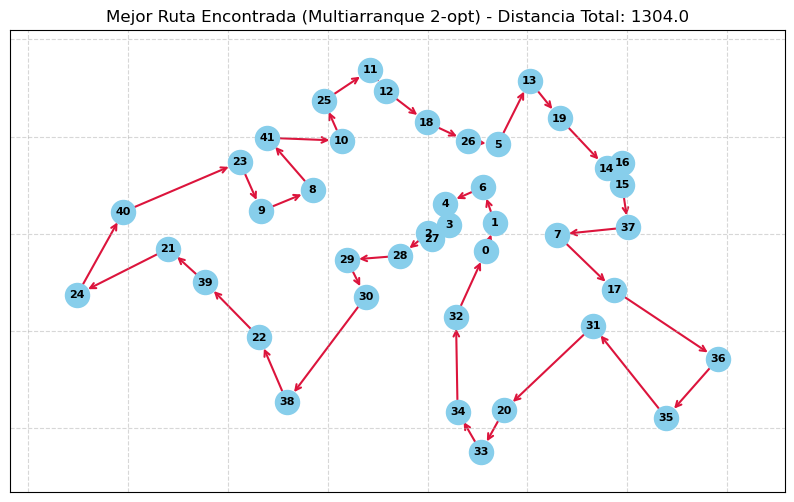

In [37]:
# Seleccionar el mejor algoritmo global y graficar su ruta
mejores_soluciones = {
    "Multiarranque 2-opt": (sol_ms, dist_ms),
    "VNS": (sol_vns, dist_vns),
    "ACO": (sol_aco, dist_aco),
    "Recocido Simulado Mejorado": (sol_sa_imp, dist_sa_imp)
}

mejor_nombre = min(mejores_soluciones, key=lambda k: mejores_soluciones[k][1])
sol_optima, dist_optima = mejores_soluciones[mejor_nombre]

print(f"¡Mejor algoritmo en esta corrida: {mejor_nombre} con distancia {dist_optima:.1f}!")
plot_tsp_solution(dist_matrix, sol_optima, f"Mejor Ruta Encontrada ({mejor_nombre})")